# Protein Contact Map — from PDB to Network

**Goal:** starting from a real protein structure, build and visualize a *contact map* — a classic tool in structural bioinformatics and, as you will see, a natural application of network science.

We will work with the **RSV F protein** (Respiratory Syncytial Virus Fusion protein), an important drug and vaccine target.  
PDB entry: **4JHW** — prefusion RSV F trimer (McLellan et al., *Science* 2013).

### The pipeline (4 steps)

```
PDB file  →  Cα coordinates  →  distance matrix  →  contact map  →  network
```

### What is a contact map?
Two residues are in *contact* if their Cα atoms are closer than a threshold $d_c$ (commonly **8 Å**).  
The contact map is the **binary adjacency matrix** of this condition:

$$C_{ij} = \begin{cases} 1 & \text{if } \|r_i - r_j\| \leq d_c \\ 0 & \text{otherwise} \end{cases}$$

---
## Step 1 — Install & Import Libraries

In [1]:
# Install if needed (uncomment)
# %pip install biopython networkx matplotlib numpy --quiet

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from Bio.PDB import PDBList, PDBParser

print("Libraries ready.")

/Users/fdurazzi/.venvs/base/lib/python3.13/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /Users/fdurazzi/.venvs/base/lib/python3.13/site-packages
  warnings.warn(


Libraries ready.


---
## Step 2 — Download the RSV F Protein Structure from PDB

The **Protein Data Bank (PDB)** is the main public repository for 3D protein structures determined by X-ray crystallography, NMR, or cryo-EM.

We download a chosen protein using BioPython's `PDBList`. The file is saved locally as a compressed `.ent` file.

In [26]:
PDB_ID = "3RRR"   # RSV F protein, post-fusion conformation

pdbl = PDBList()
pdb_file = pdbl.retrieve_pdb_file(PDB_ID, file_format="pdb", pdir="data")

print(f"Downloaded: {pdb_file}")

Downloaded: data/pdb3rrr.ent


---
## Step 3 — Parse the Structure & Extract Cα Coordinates

A PDB file contains a hierarchy:  
`Structure → Model → Chain → Residue → Atom`

For the contact map we only need the **Cα atom** (alpha carbon) of each residue — one point per amino acid.  
We work with **chain A** (one protomer of the trimer).

In [29]:
parser = PDBParser(QUIET=True)
structure = parser.get_structure(PDB_ID, pdb_file)

available_chains = [c.id for c in structure[0].get_chains()]
print(f"Available chains: {available_chains}")

# Pick one chain explicitly for the tutorial
CHAIN = 'B'
print(f"Using chain: {CHAIN}")

# Collect Cα coordinates and residue labels for chain A
ca_coords = []
res_labels = []

for residue in structure[0][CHAIN]:
    # skip HETATM records (ligands, water)
    if residue.get_id()[0] != " ":
        continue
    if "CA" in residue:
        ca_coords.append(residue["CA"].get_vector().get_array())
        res_labels.append(f"{residue.get_resname()} {residue.get_id()[1]}")

ca_coords = np.array(ca_coords)   # shape: (N_residues, 3)
N = len(ca_coords)
print(f"Chain {CHAIN}: {N} residues with Cα")

Available chains: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'L', 'M', 'N']
Using chain: B
Chain B: 358 residues with Cα


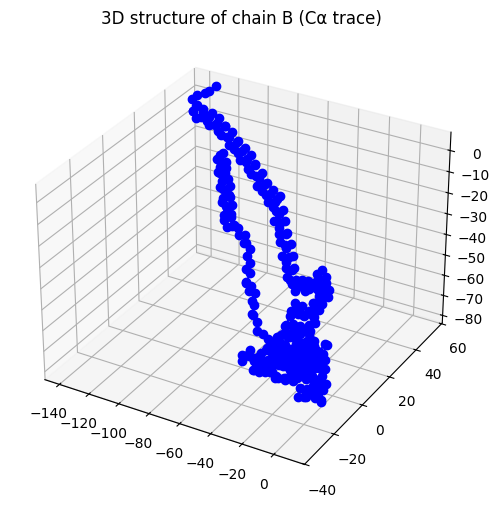

In [30]:
# Visualize the 3D structure of the chain
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(ca_coords[:, 0], ca_coords[:, 1], ca_coords[:, 2], marker='o', linestyle='-', color='blue')
ax.set_title(f"3D structure of chain {CHAIN} (Cα trace)")
plt.show()

---
## Step 4 — Compute the Distance Matrix

The pairwise Euclidean distance between all Cα atoms gives an $N \times N$ matrix.  
Here we compute it with **explicit double loops** so every step is transparent:

$$d_{ij} = \| r_i - r_j \|_2$$

In [31]:
# Distance matrix with explicit loops (didactic version)
dist_matrix = np.zeros((N, N), dtype=float)

for i in range(N):
    xi, yi, zi = ca_coords[i]
    for j in range(N):
        xj, yj, zj = ca_coords[j]
        dx = xi - xj
        dy = yi - yj
        dz = zi - zj
        dist_matrix[i, j] = np.sqrt(dx * dx + dy * dy + dz * dz)

# Show first 5x5 block to see raw values
print("Distance matrix (first 5x5 block):")
print(np.round(dist_matrix[:5, :5], 2))

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Min distance (self): {dist_matrix.min():.1f} Å")
print(f"Max distance: {dist_matrix.max():.1f} Å")

Distance matrix (first 5x5 block):
[[ 0.    3.83  6.72  9.87 12.62]
 [ 3.83  0.    3.8   6.4   9.03]
 [ 6.72  3.8   0.    3.8   6.34]
 [ 9.87  6.4   3.8   0.    2.84]
 [12.62  9.03  6.34  2.84  0.  ]]
Distance matrix shape: (358, 358)
Min distance (self): 0.0 Å
Max distance: 175.2 Å


---
## Step 5 — Build the Contact Map

Apply the threshold $d_c = 8$ Å. We also **exclude** trivial neighbours: residues $i$ and $i \pm 1$ are always close in sequence (peptide bond), so they are not informative contacts.

> **Try changing `D_CUTOFF`** — what happens at 6 Å? At 12 Å?

In [ ]:
D_CUTOFF = 8.0   # Ångström — standard threshold for Cα contact maps
SEQ_SEPARATION = 2  # exclude |i-j| <= 2 (trivial backbone contacts)

# Build contact map with explicit loops
contact_map = np.zeros((N, N), dtype=int)
contacts_list = []


for i in range(N):
    for j in range(N):
        # Keep only non-trivial pairs
        if i == j or abs(i - j) <= SEQ_SEPARATION:
            continue

        if dist_matrix[i, j] <= D_CUTOFF:
            contact_map[i, j] = 1
            # store each undirected edge once
            if i < j:
                contacts_list.append((i, j, dist_matrix[i, j]))

n_contacts = len(contacts_list)

print("First 10 contacts (i, j, distance):")
for c in contacts_list[:10]:
    print(f"{c[0]:3d}  {c[1]:3d}  {c[2]:5.2f} Å")
print(f"Number of contacts (d ≤ {D_CUTOFF} Å, |i-j| > {SEQ_SEPARATION}): {n_contacts}")
print(f"Average degree: {2 * n_contacts / N:.1f} contacts/residue")

First 10 contacts (i, j, distance):
  1    7   7.57 Å
  2    5   6.54 Å
  2    7   7.03 Å
  3    6   6.96 Å
  3    7   5.79 Å
  4    7   5.86 Å
  6    9   5.40 Å
  6   10   6.48 Å
  7   10   5.19 Å
  7   11   6.08 Å
Number of contacts (d ≤ 8.0 Å, |i-j| > 2): 756
Average degree: 4.2 contacts/residue


---
## Step 6 — Visualize the Contact Map (heatmap)

The contact map plotted as an image is the classic representation in structural bioinformatics.  
- **Axes** = residue index along the chain  
- **Dots** = pairs of residues in contact  
- The main diagonal (excluded) would be self-contacts  
- Short-range contacts (near the diagonal) → local secondary structure (α-helices, β-strands)  
- Long-range contacts (far from diagonal) → tertiary structure folds

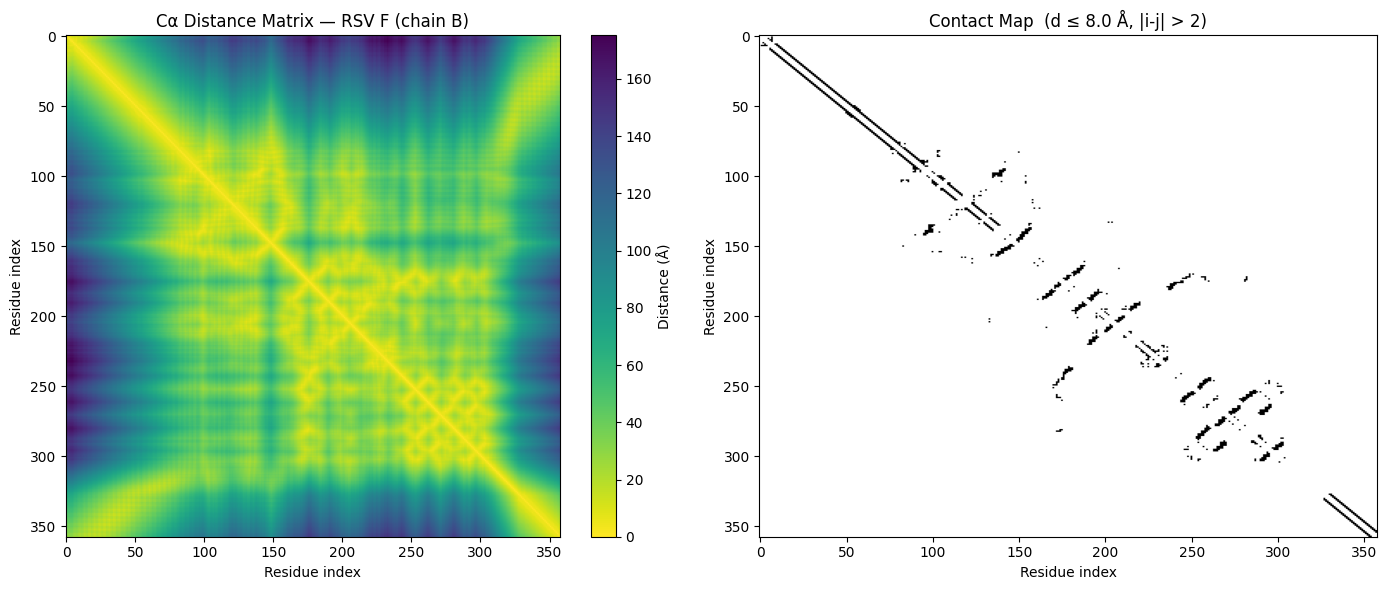

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: distance matrix (continuous)
im0 = axes[0].imshow(dist_matrix, cmap="viridis_r", aspect="auto")
axes[0].set_title(f"Cα Distance Matrix — RSV F (chain {CHAIN})")
axes[0].set_xlabel("Residue index")
axes[0].set_ylabel("Residue index")
plt.colorbar(im0, ax=axes[0], label="Distance (Å)")

# Right: binary contact map
axes[1].imshow(contact_map, cmap="Greys", aspect="auto")
axes[1].set_title(f"Contact Map  (d ≤ {D_CUTOFF} Å, |i-j| > {SEQ_SEPARATION})")
axes[1].set_xlabel("Residue index")
axes[1].set_ylabel("Residue index")

plt.tight_layout()
plt.show()

---
## Step 7 — Build a Network from the Contact Map

The contact map **is** an adjacency matrix.  
Each residue → **node**; each contact → **edge**.  
We use NetworkX to build the graph directly from the matrix.

In [34]:
# Build graph explicitly from contact matrix
G = nx.Graph()

# 1) Add one node per residue
for i in range(N):
    G.add_node(res_labels[i], index=i)

# 2) Add one edge per contact (upper triangle only)
for i in range(N):
    for j in range(i + 1, N):
        if contact_map[i, j] == 1:
            G.add_edge(res_labels[i], res_labels[j], distance=float(dist_matrix[i, j]))

print(f"Nodes (residues): {G.number_of_nodes()}")
print(f"Edges (contacts): {G.number_of_edges()}")
print(f"Average degree:   {2 * G.number_of_edges() / G.number_of_nodes():.1f}")

Nodes (residues): 358
Edges (contacts): 756
Average degree:   4.2


Now we count how many connected components are there, to ensure the network is not eccessively fragmented.
We do this manually, by computing the network Laplacian matrix L and counting how many 

In [42]:
# Laplacian
A= nx.adjacency_matrix(G).todense()
D = np.diag(np.sum(A, axis=1))  # degree matrix
L = D - A

# Eigevalues
eigenvalues, eigenvectors = np.linalg.eigh(L)
print("Smallest eigenvalues:")
print(eigenvalues[:50])

Smallest eigenvalues:
[-1.40022955e-15 -1.19495660e-15 -1.14278417e-15 -9.52050826e-16
 -6.81016238e-16 -6.77139114e-17  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  5.12007907e-16  6.95731791e-16  1.73197185e-15
  1.91751315e-15  5.71918864e-03  1.91306053e-02  6.59926315e-02
  7.40695364e-02  1.46698396e-01  1.86052607e-01  2.05426741e-01
  2.52043846e-01  3.15624308e-01  3.42417079e-01  3.53811933e-01
  4.06464488e-01  4.47711810e-01  5.00997071e-01  5.49355884e-01
  5.73938907e-01  6.07188598e-01]


In [43]:
n_components = np.sum(eigenvalues < 1e-5)
print(f"Number of connected components: {n_components}")

Number of connected components: 33


In [44]:
# Using NetworkX built-in function for connected components
components = list(nx.connected_components(G))
print(f"Number of connected components (NetworkX): {len(components)}")

Number of connected components (NetworkX): 33


---
## Step 8 — Visualize the Contact Network


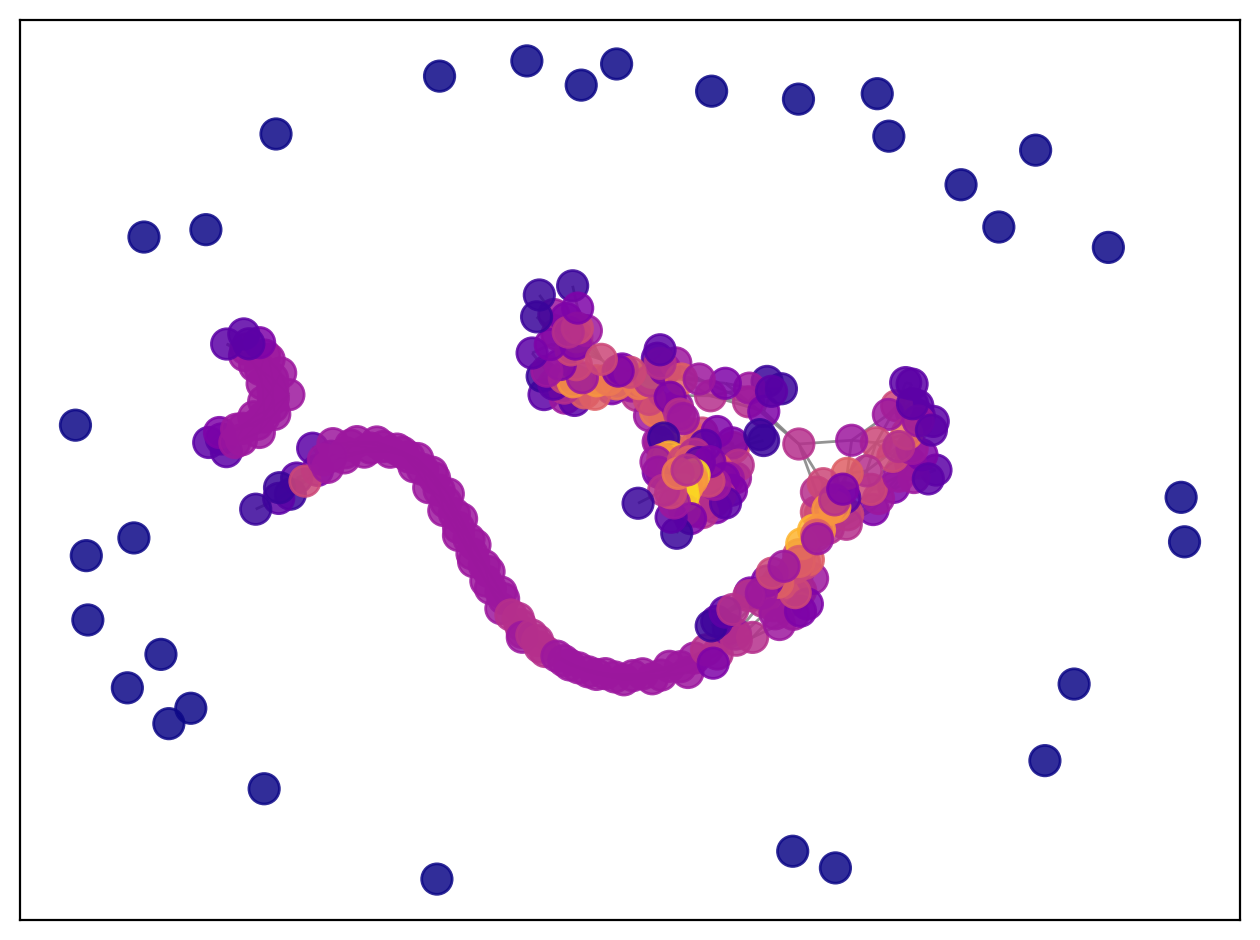

In [35]:
# Node degree (used for colour)
degrees = dict(G.degree())
node_colors = [degrees[n] for n in G.nodes()]

fig = plt.figure(dpi=200)

# --- Option A: spring layout ---
pos_spring = nx.spring_layout(G, seed=42)
nx.draw_networkx(G, pos=pos_spring, 
                 node_color=node_colors, cmap="plasma",
                 node_size=120, font_size=5,
                 edge_color="grey", alpha=0.85, with_labels=False)


sm = plt.cm.ScalarMappable(cmap="plasma",
     norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
plt.colorbar(sm, ax=axes, label="Degree (number of contacts)", shrink=0.6)
plt.tight_layout()
plt.show()

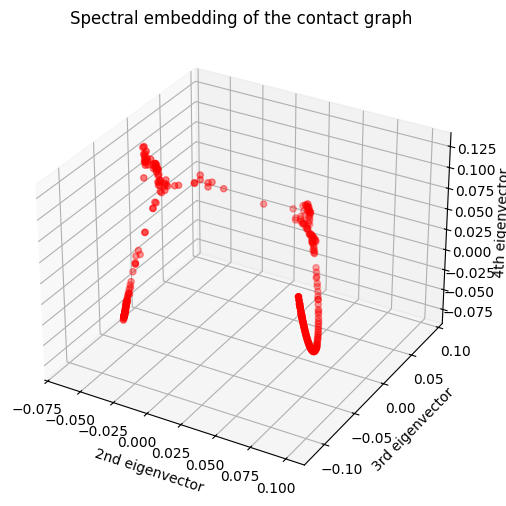

In [46]:
# 3D scatter plot using Laplacian eigevectors for the largest connected component

# Extract the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc)

A= nx.adjacency_matrix(G_sub).todense()
D = np.diag(np.sum(A, axis=1))  # degree matrix
L = D - A
eigenvalues, eigenvectors = np.linalg.eigh(L)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(eigenvectors[:, 1], eigenvectors[:, 2], eigenvectors[:, 3], c='red', marker='o')
ax.set_title("Spectral embedding of the contact graph")
ax.set_xlabel("2nd eigenvector")
ax.set_ylabel("3rd eigenvector")
ax.set_zlabel("4th eigenvector")
plt.show()

In [47]:
eigenvalues[:10]

array([-9.68073605e-16,  5.71918864e-03,  1.91306053e-02,  6.59926315e-02,
        7.40695364e-02,  1.46698396e-01,  1.86052607e-01,  2.05426741e-01,
        3.15624308e-01,  3.42417079e-01])

---
## Step 9 — Basic Network Properties

Now that we have the protein as a graph, we can apply all the network analysis tools you already know.

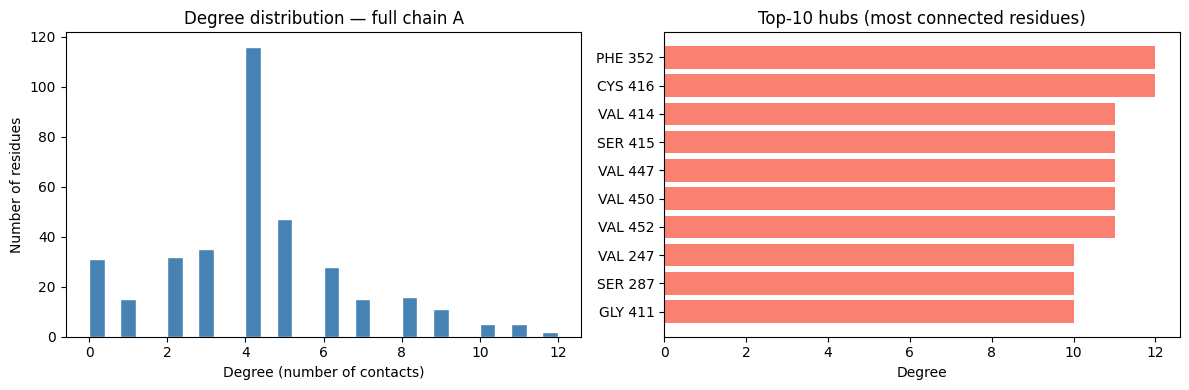

Clustering coefficient (avg): 0.077
Average shortest path (LCC):  12.13


In [36]:
# --- Degree distribution ---
degrees_all = [d for _, d in G.degree()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(degrees_all, bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Degree (number of contacts)")
axes[0].set_ylabel("Number of residues")
axes[0].set_title("Degree distribution — full chain A")

# Identify top-10 hubs (highest degree residues)
top_hubs = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
labels, vals = zip(*top_hubs)
axes[1].barh(labels, vals, color="salmon")
axes[1].set_xlabel("Degree")
axes[1].set_title("Top-10 hubs (most connected residues)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# --- Global metrics ---
print(f"Clustering coefficient (avg): {nx.average_clustering(G):.3f}")
lcc = G.subgraph(max(nx.connected_components(G), key=len))
print(f"Average shortest path (LCC):  {nx.average_shortest_path_length(lcc):.2f}")

---
## Summary

| Step | What we did | Tool |
|------|-------------|------|
| 1 | Downloaded 3D structure of RSV F protein | `Bio.PDB.PDBList` |
| 2 | Extracted Cα atom coordinates | `Bio.PDB.PDBParser` |
| 3 | Computed all pairwise distances | `numpy` broadcasting |
| 4 | Thresholded to get a binary contact map | numpy comparison |
| 5 | Visualized as heatmap | `matplotlib.imshow` |
| 6 | Converted to a graph | `networkx.from_numpy_array` |
| 7 | Visualized and analysed the network | `networkx` |

### Questions to explore
- How does the contact map change with a different cutoff?
- Are the top-degree residues biologically important (e.g. in the antigenic site Ø)?
- How does chain A compare to chain B (the other protomer)?
- Is the degree distribution similar to a random graph? To a scale-free network?